# Evaluate the HPC-trained checkpoint (defaultSpot v2, seed 42, 20 epochs)

Retrieved from cHARISMa job `4278194` per `HANDOFF_hgnd_run_2026-08-26.md`.

| Field | Value |
|---|---|
| Checkpoint | `checkpoints_hpc/defaultSpot_v2_seed42_20ep_after4278192/model.pt` |
| Arch | `net_default`, `hidden_channels=512`, `num_layers=8` |
| Best epoch (train-loss policy) | 18 (train 1.2681 / val 1.3539) |
| Schema | v2 (cluster + events + sides). Local cache is v1, but `net_default` only reads hits/clusters, so `allow_stale_schema=True` is safe. |
| Split | seed=42, train_frac=0.5 → held-out **test** half (100 k graphs) |
| Device budget | laptop-safe, preload capped at 1.5 GB, `PYTORCH_ENABLE_MPS_FALLBACK=1` |

The notebook loads the checkpoint on the laptop, runs inference on the exact seed-42 test split of the local `defaultSpot` cache, saves per-hit/per-cluster/per-edge prediction pickles, and reports classification, energy-regression, and multiplicity metrics.

In [1]:
import os, sys, time, pathlib

os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')

NB_DIR   = pathlib.Path.cwd().resolve()
REPO_DIR = NB_DIR.parent
PKG_ROOT = REPO_DIR.parent
for p in (str(PKG_ROOT),):
    if p not in sys.path:
        sys.path.insert(0, p)

%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch_geometric.loader import DataLoader

from HGNDRecoGNN import device as device_mod
from HGNDRecoGNN import models as model_registry
from HGNDRecoGNN.data.graph_dataset import HGNDGraphDataset, SCHEMA_V
from HGNDRecoGNN.training import predict, load_checkpoint, TrainConfig
from HGNDRecoGNN.training.train import build_loaders
from HGNDRecoGNN.training.eval import save_predictions
from HGNDRecoGNN.analysis import metrics as M

print('torch', torch.__version__, ' cuda', torch.cuda.is_available(), ' mps', torch.backends.mps.is_available())
print('repo :', REPO_DIR)
print('sched schema_v (code):', SCHEMA_V)

torch 2.7.1  cuda False  mps True
repo : /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN
sched schema_v (code): 2


In [2]:
CKPT_PATH   = REPO_DIR / 'checkpoints_hpc' / 'defaultSpot_v2_seed42_20ep_after4278192' / 'model.pt'
DATA_ROOT   = REPO_DIR / 'notebooks' / 'cache' / 'ndet_dataset_smash_defaultSpot'
OUT_DIR     = REPO_DIR / 'notebooks' / 'results' / 'hpc_defaultSpot_v2_seed42'

SUFFIX          = 'hpc'
BATCH_SIZE      = 128           # laptop-safe; scoring only, no gradients
PRELOAD_MAX_GB  = 1.5           # trims preload footprint on 18 GB laptop
SEED            = 42
TRAIN_FRAC      = 0.5           # reproduces the HPC-training split
DEVICE          = None          # auto (cuda → mps → cpu)

OUT_DIR.mkdir(parents=True, exist_ok=True)
assert CKPT_PATH.exists(), f'missing checkpoint at {CKPT_PATH}'
assert DATA_ROOT.exists(), f'missing dataset root at {DATA_ROOT}'
print('ckpt :', CKPT_PATH)
print('data :', DATA_ROOT)
print('out  :', OUT_DIR)

ckpt : /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/checkpoints_hpc/defaultSpot_v2_seed42_20ep_after4278192/model.pt
data : /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/cache/ndet_dataset_smash_defaultSpot
out  : /Users/vovvy/Project/BM@N/HGND/HGNDRecoGNN/notebooks/results/hpc_defaultSpot_v2_seed42


## 1. Load the checkpoint

`load_checkpoint` parses the v1 checkpoint format (state_dict + arch metadata) and returns a `Checkpoint` dataclass. We only build the model **after** reading the arch spec, so kwargs (`hidden_channels`, `num_layers`) come from the training run rather than from the notebook.

In [3]:
ckpt = load_checkpoint(str(CKPT_PATH))
print(f'arch          : {ckpt.arch_name}')
print(f'arch_kwargs   : {ckpt.arch_kwargs}')
print(f'best epoch    : {ckpt.epoch}  (checkpoint policy: save_best_on=train per HANDOFF)')
print(f'metrics       : {ckpt.metrics}')
print(f'schema_version: {ckpt.schema_version}')
print(f'format_version: {ckpt.format_version}')
print(f'params        : {sum(v.numel() for v in ckpt.state_dict.values()):,}')

arch          : net_default
arch_kwargs   : {'hidden_channels': 512, 'num_layers': 8}
best epoch    : 18  (checkpoint policy: save_best_on=train per HANDOFF)
metrics       : {'train_loss': 1.2681354612720257, 'val_loss': 1.3539286882293469}
schema_version: 2
format_version: 1
params        : 12,483,273


## 2. Load the local defaultSpot cache

The local cache is schema-v1 (preprocessed before the v2 refactor), but `net_default` only consumes the `hits` and `clusters` node/edge types, so `allow_stale_schema=True` reuses the on-disk shards without a rebuild. `preload(max_gb=1.5)` trims shard count if the preload footprint would exceed the budget.

In [4]:
t0 = time.time()
dataset = HGNDGraphDataset(
    root=str(DATA_ROOT),
    hits_csv_dir=str(DATA_ROOT),
    allow_stale_schema=True,
)
dataset.preload(max_gb=PRELOAD_MAX_GB)
print(f'|dataset| = {len(dataset):,} graphs   ({time.time()-t0:.1f}s to preload)')

[HGNDGraphDataset] WARNING: loading shards with schema v1 while code expects v2. Downstream code may crash or produce wrong results.
preload(): 196 shards ≈ 1.5 GB exceeds max_gb=1.5 — trimming to 190 shards to avoid OOM
Preloading 190 shards into memory … 

194208 graphs loaded in 202.3s (~57 MB tensor data)
|dataset| = 194,208 graphs   (202.8s to preload)


## 3. Build the model, load weights, plan device

Some `net_default` submodules use lazy PyG layers (`SAGEConv(-1, ...)`). We prime them with a single-graph forward before restoring the state dict, otherwise `load_state_dict` fails because lazy weights don't exist yet.

In [5]:
model, spec = model_registry.get(ckpt.arch_name, dataset, **ckpt.arch_kwargs)

# Prime lazy modules on a small batch so state_dict shapes match.
# eval() + batch_size>1 avoids BatchNorm's "need more than 1 value per
# channel when training" error; the running buffers used here are
# overwritten a moment later by load_state_dict.
model.eval()
with torch.no_grad():
    _probe_loader = DataLoader(dataset, batch_size=8, shuffle=False)
    _probe = next(iter(_probe_loader))
    spec.forward_fn(model, _probe)

missing, unexpected = model.load_state_dict(ckpt.state_dict, strict=False)
print(f'load_state_dict: missing={len(missing)}  unexpected={len(unexpected)}')
if missing:
    print(' first missing   :', missing[:5])
if unexpected:
    print(' first unexpected:', unexpected[:5])

plan = device_mod.plan_for(model, DEVICE, cpu_pinned=spec.default_cpu_pinned or None)
device_mod.to_device(model, plan)
print(device_mod.summarize(plan))
model.eval();

load_state_dict: missing=0  unexpected=0
device=mps  cpu_pinned=[cluster_conv_cpu,clclass_out_cpu,clenergy_out_cpu,cl_edge_out_cpu]


## 4. Reproduce the seed-42 test split and run inference

`build_loaders` uses the same `torch.manual_seed(cfg.seed) → random_split(...)` that the HPC training used with `train_frac=0.5`, so the returned test loader is the exact held-out half of `defaultSpot`.

In [6]:
cfg = TrainConfig(batch_size=BATCH_SIZE, seed=SEED, train_frac=TRAIN_FRAC)
_train_loader, test_loader = build_loaders(dataset, cfg)
print(f'train split size : {len(_train_loader.dataset):,}')
print(f'test  split size : {len(test_loader.dataset):,}')

pkl_paths = {k: OUT_DIR / f'pred_{k}_{SUFFIX}.pkl' for k in ('hits', 'clusters', 'edges')}
if all(p.exists() for p in pkl_paths.values()):
    print('all three prediction pickles already exist — loading from disk')
    preds = {k: pd.read_pickle(p) for k, p in pkl_paths.items()}
else:
    t0 = time.time()
    preds = predict(model, test_loader, plan=plan, forward_fn=spec.forward_fn)
    print(f'inference finished in {time.time()-t0:.1f}s')
    paths = save_predictions(preds, str(OUT_DIR), suffix=SUFFIX)
    for k, p in paths.items():
        print(f'  saved {k:9s} → {p}')

hits_df, clusters_df, edges_df = preds['hits'], preds['clusters'], preds['edges']
print(f'  hits     : {len(hits_df):>10,} rows')
print(f'  clusters : {len(clusters_df):>10,} rows')
print(f'  edges    : {len(edges_df):>10,} rows')

train split size : 97,104
test  split size : 97,104
all three prediction pickles already exist — loading from disk
  hits     :    912,792 rows
  clusters :    260,869 rows
  edges    :  4,764,010 rows


## 5. Classification: hit / cluster / edge ROC + AUC and threshold curves

  hit  ROC AUC : 0.9560   AP : 0.8113
  clu  ROC AUC : 0.9444   AP : 0.8067
  edge ROC AUC : 0.9492   AP : 0.9900


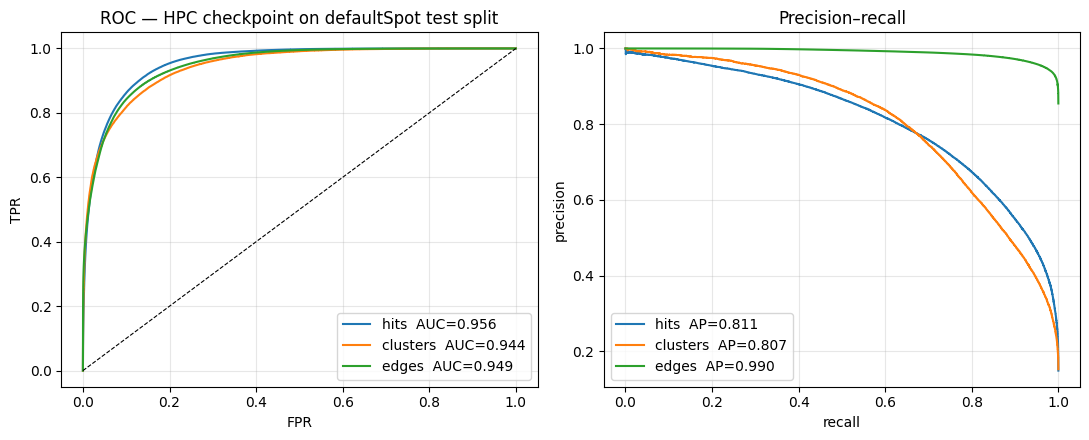

In [7]:
hit_curves  = M.classifier_curves(hits_df.score.values,       hits_df.label.values)
cl_curves   = M.classifier_curves(clusters_df.cl_score.values, clusters_df.cl_label.values)
edge_curves = M.classifier_curves(edges_df.link_score.values,  edges_df.link_label.values)

print(f'  hit  ROC AUC : {hit_curves.roc_auc:.4f}   AP : {hit_curves.pr_ap:.4f}')
print(f'  clu  ROC AUC : {cl_curves.roc_auc:.4f}   AP : {cl_curves.pr_ap:.4f}')
print(f'  edge ROC AUC : {edge_curves.roc_auc:.4f}   AP : {edge_curves.pr_ap:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for c, lbl in [(hit_curves, 'hits'), (cl_curves, 'clusters'), (edge_curves, 'edges')]:
    axes[0].plot(c.roc_fpr, c.roc_tpr, label=f'{lbl}  AUC={c.roc_auc:.3f}')
    axes[1].plot(c.pr_recall, c.pr_precision, label=f'{lbl}  AP={c.pr_ap:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC — HPC checkpoint on defaultSpot test split')
axes[0].legend(loc='lower right')
axes[1].set(xlabel='recall', ylabel='precision', title='Precision–recall')
axes[1].legend(loc='lower left')
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_pr.png', dpi=140, bbox_inches='tight')
plt.show()

Operating point t = 0.5 :
  tp=25,273  fp=5,811  fn=14,690
  purity     = 0.8131
  efficiency = 0.6324
  F1         = 0.7114
per-event detection eff (t=0.5) : 0.7439


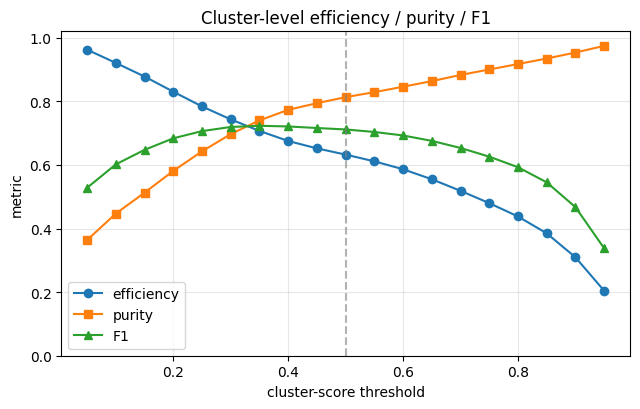

,threshold,tp,fp,fn,purity,efficiency,fake_frac,f1
0,0.05,38457,67212,1506,0.363938,0.962315,0.636062,0.528139
1,0.10,36791,45535,3172,0.446894,0.920627,0.553106,0.601706
2,0.15,35080,33332,4883,0.512776,0.877812,0.487224,0.647382
3,0.20,33175,23911,6788,0.581141,0.830143,0.418859,0.683675
4,0.25,31322,17409,8641,0.642753,0.783775,0.357247,0.706294


In [8]:
thr_df = M.efficiency_purity_vs_threshold(clusters_df, thresholds=np.linspace(0.05, 0.95, 19))
wp = thr_df.iloc[(thr_df.threshold - 0.5).abs().argmin()]
print('Operating point t = 0.5 :')
print(f'  tp={int(wp.tp):,d}  fp={int(wp.fp):,d}  fn={int(wp.fn):,d}')
print(f'  purity     = {wp.purity:.4f}')
print(f'  efficiency = {wp.efficiency:.4f}')
print(f'  F1         = {wp.f1:.4f}')
print(f'per-event detection eff (t=0.5) : {M.per_event_detection_efficiency(clusters_df, threshold=0.5):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.2))
ax.plot(thr_df.threshold, thr_df.efficiency, 'o-', label='efficiency')
ax.plot(thr_df.threshold, thr_df.purity,     's-', label='purity')
ax.plot(thr_df.threshold, thr_df.f1,         '^-', label='F1')
ax.axvline(0.5, ls='--', color='gray', alpha=0.6)
ax.set(xlabel='cluster-score threshold', ylabel='metric',
       title='Cluster-level efficiency / purity / F1', ylim=(0, 1.02))
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'efficiency_purity_vs_threshold.png', dpi=140, bbox_inches='tight')
plt.show()
thr_df.head()

## 6. Energy regression: $E_{\mathrm{pred}}$ vs $E_{\mathrm{true}}$ and resolution

signal clusters above t=0.5 : 25,273


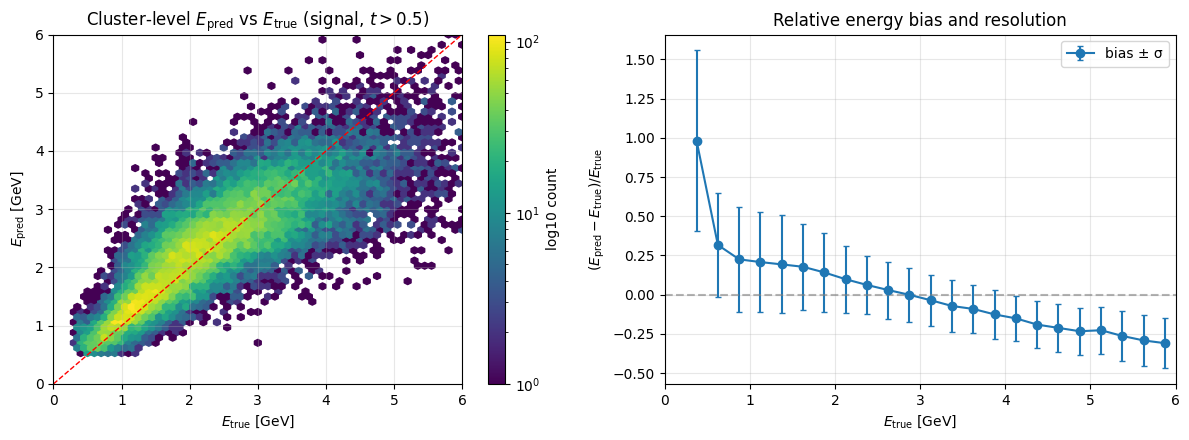

,ekin_lo,ekin_hi,ekin_mid,count,mean,std
0,0.25,0.50,0.375,157,0.981248,0.575724
1,0.50,0.75,0.625,599,0.317179,0.332064
2,0.75,1.00,0.875,1184,0.225456,0.333570
3,1.00,1.25,1.125,1826,0.208088,0.321349
4,1.25,1.50,1.375,2092,0.193295,0.311651
5,1.50,1.75,1.625,2222,0.178088,0.274727
6,1.75,2.00,1.875,2414,0.141968,0.249019
7,2.00,2.25,2.125,2293,0.098794,0.214237
8,2.25,2.50,2.375,2154,0.062355,0.186323
9,2.50,2.75,2.625,1994,0.029884,0.181680


In [9]:
sig = clusters_df[(clusters_df.cl_label == 1) & (clusters_df.cl_score > 0.5)
                  & (clusters_df.e_true > 0)].copy()
print(f'signal clusters above t=0.5 : {len(sig):,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 2D density: E_pred vs E_true
hb = axes[0].hexbin(sig.e_true, sig.e_pred, gridsize=60,
                    extent=(0, 6, 0, 6), bins='log', cmap='viridis', mincnt=1)
axes[0].plot([0, 6], [0, 6], 'r--', lw=1.0)
axes[0].set(xlabel=r'$E_{\mathrm{true}}$ [GeV]', ylabel=r'$E_{\mathrm{pred}}$ [GeV]',
            title=r'Cluster-level $E_{\mathrm{pred}}$ vs $E_{\mathrm{true}}$ (signal, $t>0.5$)',
            xlim=(0, 6), ylim=(0, 6))
fig.colorbar(hb, ax=axes[0], label='log10 count')
axes[0].grid(alpha=0.3)

# Bias / resolution vs E_true
res = M.energy_resolution(clusters_df, ekin_bins=np.linspace(0.0, 6.0, 25), score_threshold=0.5)
axes[1].errorbar(res.ekin_mid, res['mean'], yerr=res['std'], fmt='o-', capsize=2, label='bias ± σ')
axes[1].axhline(0, ls='--', color='gray', alpha=0.6)
axes[1].set(xlabel=r'$E_{\mathrm{true}}$ [GeV]',
            ylabel=r'$(E_{\mathrm{pred}} - E_{\mathrm{true}}) / E_{\mathrm{true}}$',
            title='Relative energy bias and resolution', xlim=(0, 6))
axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'energy_regression.png', dpi=140, bbox_inches='tight')
plt.show()
res

## 7. Multiplicity confusion at $t = 0.5$

n_reco      0      1     2    3   4  5  7
n_true                                   
0       41406   3247   127    4   0  0  0
1        6811  14609   974   24   1  0  0
2         829   2971  2185  162   7  0  0
3          84    415   551  277  16  1  0
4          11     42    88   72  19  1  0
5           0      4    17   10   7  3  1
6           0      0     1    4   4  0  0
8           0      0     0    1   0  0  0


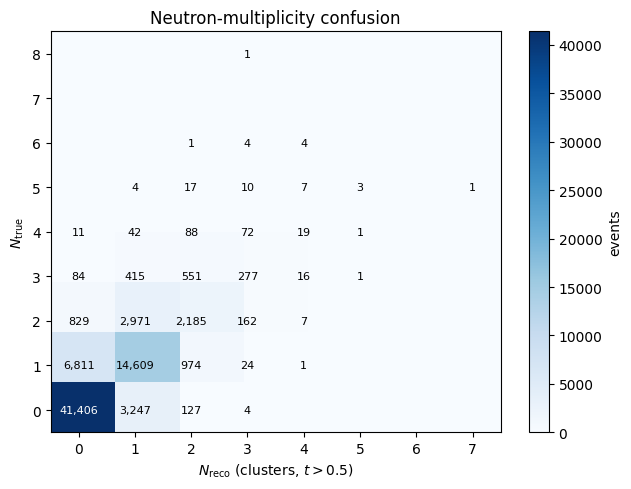

In [10]:
conf = M.multiplicity_confusion(clusters_df, threshold=0.5)
pivot = (conf.pivot(index='n_true', columns='n_reco', values='count')
             .fillna(0).astype(int))
print(pivot)

fig, ax = plt.subplots(figsize=(6.5, 5.0))
vmax = pivot.values.max()
im = ax.imshow(pivot.values, origin='lower', cmap='Blues', aspect='auto',
               extent=[pivot.columns.min()-0.5, pivot.columns.max()+0.5,
                       pivot.index.min()-0.5,   pivot.index.max()+0.5])
for i, n_true in enumerate(pivot.index):
    for j, n_reco in enumerate(pivot.columns):
        v = pivot.values[i, j]
        if v > 0:
            ax.text(n_reco, n_true, f'{v:,}', ha='center', va='center',
                    color='white' if v > 0.5 * vmax else 'black', fontsize=8)
ax.set(xlabel=r'$N_{\mathrm{reco}}$ (clusters, $t>0.5$)',
       ylabel=r'$N_{\mathrm{true}}$', title='Neutron-multiplicity confusion')
fig.colorbar(im, ax=ax, label='events')
plt.tight_layout()
plt.savefig(OUT_DIR / 'multiplicity_confusion.png', dpi=140, bbox_inches='tight')
plt.show()

## 8. Summary

Numbers printed in-line above are what to quote back to the paper draft's Section 5 (performance) and Section 6 (sensitivity, once matched to the smoke-scale comparison). The three prediction pickles under
`notebooks/results/hpc_defaultSpot_v2_seed42/pred_*_hpc.pkl` are drop-in compatible with `results_smash.ipynb` and with the sensitivity CLI (`--dataset defaultSpot=<...>/pred_clusters_hpc.pkl`).